# Notebook 4 — Machine Learning Pipeline (Valence)

**Objective.** Train and compare three classifiers that predict the
**valence** label (`negative` / `neutral` / `positive`) from the **plant bioelectric features**
of each 30-second window, and identify the best-performing model.

This notebook mirrors `04_01_ml_pipeline_emotion.ipynb`, which predicts the
crossed `label` (5 classes). Here the target is instead **`valence_direction`** —
one of the two independent axes produced by `02_emotion_labelling.ipynb`
(see its §4.8). The other axis, the crossed `label`, and every HRV/FER
column are **excluded from the features** — the model sees **only the plant
signal**, nothing derived from heart rate or the face.

**Models compared**
1. **Random Forest** (bagged decision trees)
2. **XGBoost** (gradient-boosted trees)
3. **Neural Network** (multi-layer perceptron)

**Pipeline overview**
1. Load the consolidated dataset (output of Notebook 1 / `03_dataset_creation.ipynb`)
2. Select plant-bioelectric features only, in two representations (`raw`, `session_norm`) — see §3
3. Clean: handle missing values, encode categoricals, drop redundant columns
4. Split into train / validation / test, participant-grouped (`StratifiedGroupKFold`) — no participant leakage
5. Scale features
6. Hyperparameter tuning via **nested Grid Search** (per outer fold, per model)
7. Evaluate: accuracy, F1, ROC-AUC, confusion matrix, classification report
8. Compare models, inspect feature importance, discuss findings

> **Note on dataset size.** This is an exploratory study (N ≈ 10–15
> participants). The absolute scores matter less than the *relative* comparison
> of the three approaches and the methodology, which is built to scale to a
> larger cohort without changes.


## 1  Imports & Configuration

We fix a global `RANDOM_STATE` for full reproducibility. XGBoost is optional —
if it is not installed the notebook still runs the other two models and says so.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedGroupKFold
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("xgboost not installed — pip install xgboost (XGBoost model will be skipped)")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET_COL = "valence_direction"   # the axis this notebook predicts

DATASET_CSV = Path("../data/datasets/consolidated_dataset.csv")   # output of Notebook 1
print(f"Dataset: {DATASET_CSV.resolve()}")
print(f"Target column: {TARGET_COL}")
print(f"XGBoost available: {XGBOOST_OK}")


Dataset: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\consolidated_dataset.csv
Target column: valence_direction
XGBoost available: True


## 2  Load the Consolidated Dataset

We load the single CSV produced by Notebook 1 and take a first look at its
shape, columns and the class balance of the target (`valence_direction`).


In [2]:
df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Target (valence_direction) distribution:")
print(df[TARGET_COL].value_counts().to_string())
print("\nClass balance:")
print(df[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str).add(' %').to_string())
df.head()


Loaded 284 rows x 83 columns

Target (valence_direction) distribution:
valence_direction
neutral     105
negative     96
positive     83

Class balance:
valence_direction
neutral     37.0 %
negative    33.8 %
positive    29.2 %


,session_id,participant_id,session_date,win_start_ms,win_end_ms,label,valence_direction,arousal_level,reason,label_type,...,bp_5_15_snorm,bp_15_30_snorm,band_power_sum_snorm,ratio_bp1_5_bp5_15_snorm,ratio_bp1_5_total_snorm,hjorth_activity_snorm,hjorth_mobility_snorm,hjorth_complexity_snorm,spectral_entropy_snorm,spike_rate_snorm
0,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347110256,1783347140256,positive calm,positive,calm,clear,proxy,...,-0.7108,-1.2451,2.7699,-0.3041,-2.0739,2.1530,-2.6322,3.6578,2.3776,-1.1238
1,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347140256,1783347170256,neutral,positive,neutral,hrv_ambiguous,proxy,...,0.0317,-0.3474,0.6253,0.2363,-0.0892,0.3696,-0.5779,0.4954,-0.1993,-0.2220
2,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347170256,1783347200256,positive activated,positive,activated,clear,proxy,...,-0.0886,0.5174,-2.5416,0.2363,3.1361,-1.4683,1.9529,-1.8097,-1.7742,1.2798
3,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347200256,1783347230256,negative calm,negative,calm,clear,proxy,...,-0.8598,0.2343,2.3566,1.5398,-1.2696,1.7047,-0.3303,0.4395,5.1489,-0.9530
4,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347230256,1783347260256,neutral,negative,neutral,hrv_ambiguous,proxy,...,0.6463,0.2337,-0.2292,-1.3352,0.1045,0.3993,0.0319,-0.0805,0.3322,2.3613


## 3  Feature Selection & Inspection

### Target
The prediction target is **`valence_direction`** (`negative` / `neutral` / `positive`), one of the two
independent axes described in `02_emotion_labelling.ipynb` §4.6-4.8.

### Plant-bioelectric signals are the sole predictor family
Across all three ML-pipeline notebooks (`04_01_ml_pipeline_emotion.ipynb`,
`04_02_ml_pipeline_arousal.ipynb`, this notebook), every feature ever
selected into `X` is a plant-bioelectric column — nothing else.
Specifically excluded, and why:

- **HRV** (`rmssd`, `mean_hr`, `arousal_hrv`, …) and **FER** (`fer_valence`,
  `fer_arousal`, …) are exactly the signals `valence_direction` was
  *derived from* (`02_emotion_labelling.ipynb` §4.7-4.8). Feeding them back
  as predictors would be direct **target leakage** — the model would
  re-learn the labelling rule instead of the plant-signal/valence
  relationship this pipeline exists to test.
- **The other axis** (`arousal_level`) and the crossed `label` are excluded
  for the same reason: `label` is a deterministic function of
  `valence_direction` and `arousal_level`, so either would leak the target
  through the back door.
- **CO2** is tracked in `02_emotion_labelling.ipynb` (§4.6b) and consumed by
  `05_Correlation_Analysis_V02.ipynb` as a candidate environmental
  confound/context variable — not because it is believed to carry
  emotion-predictive signal itself. It is never a candidate feature here.

So HRV/FER feed label generation (02) only, CO2 feeds the independent
correlation analysis (05) only, and the plant-bioelectric columns below are
the only inputs any classifier in `04_01/02/03` ever sees.

### Candidate features — two representations
`02_emotion_labelling.ipynb` (§4.10/§4.10b) is the single place that
computes and exports these plant-derived features, so this notebook selects
from what is already in the consolidated CSV rather than re-deriving or
re-normalizing anything.

Every continuous plant feature exists in the CSV in **two representations**,
and this notebook evaluates both as separate run-throughs rather than
picking one upfront:

| Feature set | Columns |
|---|---|
| `raw` | absolute-scale `plant_mean`, `plant_median`, `plant_std`, `plant_detrend_std`, `plant_iqr`, `plant_min`, `plant_max`, `plant_range`, `plant_rms`, `plant_zcr`, `bp_0_1`, `bp_1_5`, `bp_5_15`, `bp_15_30`, `band_power_sum`, `ratio_bp1_5_bp5_15`, `ratio_bp1_5_total`, `hjorth_activity`, `hjorth_mobility`, `hjorth_complexity`, `spectral_entropy`, `spike_rate` |
| `session_norm` | the same 22 features, each re-expressed as a robust z-score against that session's own whole-session median/MAD (labelling notebook §4.10b) |
| shared (both sets) | `plant_sat_pos_frac`, `plant_sat_neg_frac`, `plant_const_flag`, `plant_quality`, `plant_dead_flag`, `plant_suspect_flag` |

Every model architecture below is tuned and evaluated **on both feature
sets**, and the pooled nested-CV macro-F1 (§11) says which representation
actually helps — nothing is assumed upfront.

We inspect each candidate for usefulness before committing.


In [3]:
# Two candidate feature lists - same 22 physical plant quantities, in their
# raw absolute-scale form and in their session-normalized form (see §3) -
# plus the flag/coverage columns shared by both. Still plant-only: no HRV/FER,
# no other axis, no crossed label, no CO2 - see §3 for why.
FEATURE_SETS = {
    "raw":          ['plant_mean', 'plant_median', 'plant_std', 'plant_detrend_std', 'plant_iqr', 'plant_min', 'plant_max', 'plant_range', 'plant_rms', 'plant_zcr', 'bp_0_1', 'bp_1_5', 'bp_5_15', 'bp_15_30', 'band_power_sum', 'ratio_bp1_5_bp5_15', 'ratio_bp1_5_total', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'spectral_entropy', 'spike_rate'] + ['plant_sat_pos_frac', 'plant_sat_neg_frac', 'plant_const_flag', 'plant_quality', 'plant_dead_flag', 'plant_suspect_flag'],
    "session_norm": ['plant_mean_snorm', 'plant_median_snorm', 'plant_std_snorm', 'plant_detrend_std_snorm', 'plant_iqr_snorm', 'plant_min_snorm', 'plant_max_snorm', 'plant_range_snorm', 'plant_rms_snorm', 'plant_zcr_snorm', 'bp_0_1_snorm', 'bp_1_5_snorm', 'bp_5_15_snorm', 'bp_15_30_snorm', 'band_power_sum_snorm', 'ratio_bp1_5_bp5_15_snorm', 'ratio_bp1_5_total_snorm', 'hjorth_activity_snorm', 'hjorth_mobility_snorm', 'hjorth_complexity_snorm', 'spectral_entropy_snorm', 'spike_rate_snorm'] + ['plant_sat_pos_frac', 'plant_sat_neg_frac', 'plant_const_flag', 'plant_quality', 'plant_dead_flag', 'plant_suspect_flag'],
}

# Keep only columns actually present (robust to schema variations)
for _name, _cols in FEATURE_SETS.items():
    FEATURE_SETS[_name] = [c for c in _cols if c in df.columns]
    print(f"[{_name}] {len(FEATURE_SETS[_name])} candidate features present.")

print()
inspect = pd.DataFrame({
    "dtype":     df[FEATURE_SETS["session_norm"]].dtypes.astype(str),
    "n_missing": df[FEATURE_SETS["session_norm"]].isna().sum(),
    "n_unique":  df[FEATURE_SETS["session_norm"]].nunique(),
})
print("\nDtype/missingness/variance (session_norm set shown; raw set mirrors it column-for-column):")
print(inspect.to_string())


[raw] 28 candidate features present.
[session_norm] 28 candidate features present.


Dtype/missingness/variance (session_norm set shown; raw set mirrors it column-for-column):
                            dtype  n_missing  n_unique
plant_mean_snorm          float64          0       276
plant_median_snorm        float64          0       279
plant_std_snorm           float64          0       280
plant_detrend_std_snorm   float64          0       282
plant_iqr_snorm           float64          0       282
plant_min_snorm           float64          0       283
plant_max_snorm           float64          0       284
plant_range_snorm         float64          0       281
plant_rms_snorm           float64          0       280
plant_zcr_snorm           float64          0       283
bp_0_1_snorm              float64          0       284
bp_1_5_snorm              float64          0       283
bp_5_15_snorm             float64          0       283
bp_15_30_snorm            float64          0       283

### Removing redundant / non-informative features

We drop features that cannot help the model, independently in each feature
set (a column can be constant in one representation and not the other,
though in practice `*_snorm` inherits whatever was constant in `raw`):

- **Constant columns** (`n_unique == 1`) carry no information.
- **`plant_quality`** is a categorical *summary* of `plant_std` / saturation; we
  keep the boolean `plant_dead_flag` / `plant_suspect_flag` instead (cleaner for
  modelling) and one-hot `plant_quality` only if it varies.
- **`plant_n_samples`** is a coverage/QA field, not a physiological signal —
  dropped if near-constant.


In [4]:
# Drop constant candidate features (no information), per feature set
for _name, _cols in FEATURE_SETS.items():
    nunique = df[_cols].nunique()
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        print(f"[{_name}] Dropping {len(constant_cols)} constant feature(s): {constant_cols}")
    _cols = [c for c in _cols if c not in constant_cols]

    if "plant_n_samples" in df.columns and df["plant_n_samples"].std() < 1e-6 and "plant_n_samples" in _cols:
        _cols.remove("plant_n_samples")
        print(f"[{_name}] Dropping 'plant_n_samples' (near-constant coverage field).")

    FEATURE_SETS[_name] = _cols
    print(f"[{_name}] {len(_cols)} features remain after redundancy removal.")

[raw] Dropping 4 constant feature(s): ['plant_sat_pos_frac', 'plant_sat_neg_frac', 'plant_const_flag', 'plant_dead_flag']
[raw] 24 features remain after redundancy removal.
[session_norm] Dropping 4 constant feature(s): ['plant_sat_pos_frac', 'plant_sat_neg_frac', 'plant_const_flag', 'plant_dead_flag']
[session_norm] 24 features remain after redundancy removal.


## 4  Preprocessing: Missing Values & Encoding

**Missing values.** Spectral features can be `NaN` for windows that were too
short or flat for a Welch PSD, or where the plant merge produced no reading
for a session, and `*_snorm` columns are `NaN` for any session with fewer
than `MIN_ML_WINDOWS` ML-grid windows (labelling notebook §4.10b). We:
- drop rows whose target (`valence_direction`) is missing or `"excluded"`,
- impute remaining numeric `NaN`s with the **median** (robust to outliers,
  computed independently per feature set).

**Categorical encoding.** `plant_quality` (if kept) is one-hot encoded once
and shared by both feature sets — it doesn't change with normalization.
Boolean flags are cast to integers (0/1).

**Quality filtering.** Windows flagged `plant_dead_flag` are electrode-failure
artefacts with no usable plant signal; we drop them from the modelling set
(kept configurable).

**Two design matrices.** Everything below (`work`, `y`) is shared between
the two feature sets — only the *columns* selected into `X` differ,
producing `X_by_set["raw"]` and `X_by_set["session_norm"]` from the same
rows.


In [5]:
DROP_DEAD_WINDOWS = True   # exclude electrode-failure windows from modelling

work = df.copy()

# 1) Drop rows with missing or excluded target
work = work.dropna(subset=[TARGET_COL]).reset_index(drop=True)
work = work[work[TARGET_COL] != "excluded"].reset_index(drop=True)

# 2) Optionally drop dead-electrode windows
if DROP_DEAD_WINDOWS and "plant_dead_flag" in work.columns:
    before = len(work)
    dead = work["plant_dead_flag"].astype(str).str.lower().isin(["true", "1"])
    work = work[~dead].reset_index(drop=True)
    print(f"Dropped {before - len(work)} dead-electrode windows "
          f"({len(work)} rows remain).")

# 3) Cast boolean flags to int
for col in ["plant_const_flag", "plant_dead_flag", "plant_suspect_flag"]:
    if col in work.columns:
        work[col] = work[col].astype(str).str.lower().isin(["true", "1"]).astype(int)

# 4) One-hot encode plant_quality once (shared by both feature sets), if present and varies
encoded_cols = []
if any("plant_quality" in cols for cols in FEATURE_SETS.values()):
    if work["plant_quality"].nunique() > 1:
        dummies = pd.get_dummies(work["plant_quality"], prefix="quality").astype(int)
        work = pd.concat([work, dummies], axis=1)
        encoded_cols = dummies.columns.tolist()
        print(f"One-hot encoded plant_quality -> {encoded_cols}")
    for _name in FEATURE_SETS:
        if "plant_quality" in FEATURE_SETS[_name]:
            FEATURE_SETS[_name].remove("plant_quality")

# 5) Build one design matrix per feature set: median-impute remaining numeric NaNs
X_by_set = {}
for _name, _cols in FEATURE_SETS.items():
    feature_cols = _cols + encoded_cols
    Xs = work[feature_cols].apply(pd.to_numeric, errors="coerce")
    n_missing = Xs.isna().sum().sum()
    if n_missing:
        print(f"[{_name}] Imputing {n_missing} missing numeric values with column medians.")
        Xs = Xs.fillna(Xs.median(numeric_only=True))
    X_by_set[_name] = Xs
    FEATURE_SETS[_name] = feature_cols

y = work[TARGET_COL].astype(str)
groups = work["participant_id"] if "participant_id" in work.columns else (
    work["proband_id"] if "proband_id" in work.columns else pd.Series(range(len(work))))

for _name, Xs in X_by_set.items():
    print(f"\n[{_name}] design matrix: {Xs.shape[0]} rows x {Xs.shape[1]} features")
    print(f"[{_name}] features: {list(Xs.columns)}")
print(f"\nTarget distribution after cleaning:")
print(y.value_counts().to_string())

Dropped 0 dead-electrode windows (284 rows remain).
One-hot encoded plant_quality -> ['quality_ok', 'quality_suspect_lowamp']

[raw] design matrix: 284 rows x 25 features
[raw] features: ['plant_mean', 'plant_median', 'plant_std', 'plant_detrend_std', 'plant_iqr', 'plant_min', 'plant_max', 'plant_range', 'plant_rms', 'plant_zcr', 'bp_0_1', 'bp_1_5', 'bp_5_15', 'bp_15_30', 'band_power_sum', 'ratio_bp1_5_bp5_15', 'ratio_bp1_5_total', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'spectral_entropy', 'spike_rate', 'plant_suspect_flag', 'quality_ok', 'quality_suspect_lowamp']

[session_norm] design matrix: 284 rows x 25 features
[session_norm] features: ['plant_mean_snorm', 'plant_median_snorm', 'plant_std_snorm', 'plant_detrend_std_snorm', 'plant_iqr_snorm', 'plant_min_snorm', 'plant_max_snorm', 'plant_range_snorm', 'plant_rms_snorm', 'plant_zcr_snorm', 'bp_0_1_snorm', 'bp_1_5_snorm', 'bp_5_15_snorm', 'bp_15_30_snorm', 'band_power_sum_snorm', 'ratio_bp1_5_bp5_15_snorm', 'ratio

## 5  Evaluation Strategy: Participant-Grouped, Stratified K-Fold

Every model architecture is tuned and evaluated on **both feature sets**
(§3) via **`StratifiedGroupKFold`** — every fold keeps class balance
*and* keeps each `participant_id`'s windows entirely on one side of the
split. Windows from the same session share that participant's plant/
electrode characteristics, so a plain (non-grouped) split would let a model
partly learn "whose signal is this" rather than purely the plant/emotion
relationship — `StratifiedGroupKFold` closes that leakage channel by
construction: a participant is never split across train and test.

This grouping is why the plant-feature normalization in
`02_emotion_labelling.ipynb` §4.10b can safely compute each session's
median/MAD from that session's own windows: once a session is always
entirely in train or entirely in test, using its own statistics never
leaks information across a fold boundary either.

Hyperparameter tuning is **nested** inside this same grouped CV (§11): a
fresh inner `StratifiedGroupKFold` search runs on each outer fold's
training data alone, so no fold's test rows ever influence the
hyperparameters used to score it. This is separate from the full-dataset
tuning pass in §7-10, which exists only to fit the model that gets
persisted for production use (§16) and to inspect feature importances
(§14) — it is not the source of any reported generalization metric. See
§11 for the exact nested procedure and §16 for why the persisted model is
tuned differently.

Every reported metric below is an out-of-fold prediction (never scored on
data used to train or tune that fold), and there is exactly one model per
(architecture, feature set) — no gating/two-stage composition.


In [6]:
for _name, Xs in X_by_set.items():
    print(f"[{_name}] {len(Xs)} rows, {groups.nunique()} participants")
print(f"Class balance: {dict(y.value_counts())}")

[raw] 284 rows, 15 participants
[session_norm] 284 rows, 15 participants
Class balance: {'neutral': np.int64(105), 'negative': np.int64(96), 'positive': np.int64(83)}


## 6  Target Encoding

Models need an integer-encoded target. Feature scaling is not a separate
manual step: §10 wraps the neural net in a
`Pipeline(StandardScaler, MLPClassifier)`, so scaling is fit correctly
inside every CV fold automatically, with no manual pre-scaled arrays and
no risk of a scaler seeing data (or participants) it should not at tuning
or evaluation time. Trees do not need scaling at all.


In [7]:
classes = sorted(y.unique())
class_to_int = {c: i for i, c in enumerate(classes)}
int_to_class = {i: c for c, i in class_to_int.items()}
y_enc = y.map(class_to_int)
print(f"Classes: {classes}  ->  encoded as {list(range(len(classes)))}")


Classes: ['negative', 'neutral', 'positive']  ->  encoded as [0, 1, 2]


## 7  Hyperparameter Grids & Full-Dataset Tuning (for feature importance + the persisted model)

For each model architecture we run **`GridSearchCV`** — exhaustively
evaluating every combination of hyperparameters in a fixed grid via
`StratifiedGroupKFold` cross-validation (§5) — **once per feature set**
(`raw`, `session_norm`), so tuning never gives one representation an unfair
advantage from reused hyperparameters. The grids are deliberately refined — 4-6 values on the
regularization-critical hyperparameters — because the coarse baseline
(2-3 values each) left the tree models pinned at the strongest setting
they were offered while still badly overfitting this small, grouped,
imbalanced dataset. Every value added here is multiplied by the nested-CV
depth in §11, so the grids are broadened where it fights overfitting and
held fixed elsewhere to keep runtime bounded.

**This is the full-dataset tuning pass, not the reported metric.** It tunes
and fits each (model, feature set) combination on **all** available data,
grouped by `participant_id` so no fold ever splits a participant, and is
used for two purposes only: the feature-importance plots (§14) and — for
whichever single combination the nested-CV comparison in §15 picks as the
winner — the model persisted for production use (§16). It is a **separate**
tuning pass from the nested procedure in §11 that produces every reported
macro-F1/accuracy/ROC-AUC number: nesting the search inside each outer fold
there is what makes that number an honest estimate of generalization: the
full-dataset tune here would leak if used for that purpose, since it lets
every fold's hyperparameters be influenced by that same fold's rows. See
§16 for the same distinction spelled out again at the point it matters.

`error_score=0` stops a single failed fit from aborting the whole search;
`return_train_score` lets us print the train-vs-CV gap as an overfitting
check.


In [8]:
CV_FOLDS = 5           # outer folds - kept at 5 despite only 15 participants (see §5/§11):
                        # more folds would leave even fewer groups per fold to stratify over.
INNER_FOLDS = 3         # inner folds for nested tuning (§11) - only ~12 participants remain
                        # once an outer fold's ~3 are held out, so 3 inner folds keeps a
                        # workable number of groups (~4) in every inner training split.
SCORING = "f1_macro"   # macro-F1: treats all classes equally

# Full-dataset CV for this section's tuning pass only (§7, see markdown above)
# - participant-grouped like every other CV object in this notebook, so no
# fold here splits a participant either, but this is NOT the nested
# procedure that produces the reported metric (that's EVAL_CV in §11).
FULL_TUNE_CV = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def tune(estimator, param_grid, X_full, y_full, groups_full, name):
    """Run GridSearchCV, grouped by participant, on the FULL dataset and
    report the best configuration. Used only for feature importance (§14)
    and the final persisted model (§16) - never for a reported metric, see
    §7's markdown for why. error_score=0 prevents a single failed fit from
    aborting the search; return_train_score enables an overfitting check."""
    search = GridSearchCV(
        estimator, param_grid=param_grid,
        scoring=SCORING, cv=FULL_TUNE_CV,
        n_jobs=-1, refit=True, verbose=0,
        return_train_score=True, error_score=0,
    )
    search.fit(X_full, y_full, groups=groups_full)
    n_fits     = len(search.cv_results_["params"])
    best_idx   = search.best_index_
    train_mean = search.cv_results_["mean_train_score"][best_idx]
    val_mean   = search.cv_results_["mean_test_score"][best_idx]
    val_std    = search.cv_results_["std_test_score"][best_idx]
    print(f"[{name}] {n_fits} parameter combinations x {CV_FOLDS} participant-grouped folds evaluated")
    print(f"[{name}] best CV {SCORING} = {val_mean:.3f} +/- {val_std:.3f}  "
          f"(train {train_mean:.3f}, gap {train_mean - val_mean:+.3f})")
    print(f"[{name}] best params = {search.best_params_}")
    return search.best_estimator_


## 8  Model 1 — Random Forest

A bagging ensemble of decision trees. Robust, needs little preprocessing, and
gives interpretable feature importances. Trees are scale-invariant — so
comparing its `raw` vs `session_norm` result is a clean test of whether the
*session-relative* framing itself carries signal, not just a rescaling
effect. `class_weight="balanced"` compensates for the class imbalance in
`label` (62% `neutral`). `max_depth`, `min_samples_leaf`, `min_samples_split` and `max_features`
are searched over a finer, regularization-focused range (§7) to fight the
train/CV overfitting the coarse baseline grid could not escape.


In [9]:
# Refined grid (see §7): the baseline [200,400] x [4,6,8] x [4,8,12] x [sqrt,log2]
# kept selecting the deepest tree it was offered while CV macro-F1 stayed near
# chance (train ~0.9, CV ~0.2) - textbook overfitting on this small
# (~284-window, 15-participant), imbalanced, participant-grouped dataset. The
# refined grid searches a finer, regularization-focused range: shallower trees,
# larger leaf/split minima, and a mid-range max_features fraction, so the
# search can settle on a genuinely well-regularized forest instead of being
# capped at the strongest setting available to it.
rf_grid = {
    "n_estimators":      [300, 600],
    "max_depth":         [2, 3, 4, 5, 6],
    "min_samples_leaf":  [2, 4, 8, 16],
    "min_samples_split": [2, 10],
    "max_features":      ["sqrt", "log2", 0.5],
}
def make_rf():
    return RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)

rf_best = {}
for fset, Xs in X_by_set.items():
    rf_best[fset] = tune(make_rf(), rf_grid, Xs, y_enc, groups, f"RandomForest [{fset}]")


[RandomForest [raw]] 240 parameter combinations x 5 participant-grouped folds evaluated
[RandomForest [raw]] best CV f1_macro = 0.401 +/- 0.090  (train 0.920, gap +0.519)
[RandomForest [raw]] best params = {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 600}


[RandomForest [session_norm]] 240 parameter combinations x 5 participant-grouped folds evaluated
[RandomForest [session_norm]] best CV f1_macro = 0.464 +/- 0.082  (train 0.718, gap +0.254)
[RandomForest [session_norm]] best params = {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}


## 9  Model 2 — XGBoost


In [10]:
if XGBOOST_OK:
    xgb_grid = {
        # Refined grid (see §7): baseline XGBoost hit train macro-F1 = 1.0 with
        # CV near chance, so the refinement targets regularization - a lower
        # learning-rate floor, stronger reg_lambda, a min_child_weight leaf
        # constraint, and row subsampling promoted from a fixed constant to a
        # tuned hyperparameter. colsample_bytree stays fixed (already low at
        # 0.7) so the grid does not explode under nested CV (§11).
        "n_estimators":      [200, 400],
        "max_depth":         [2, 3, 4],
        "learning_rate":     [0.01, 0.03, 0.05],
        "reg_lambda":        [1.0, 5.0, 10.0],
        "min_child_weight":  [1, 5],
        "subsample":         [0.7, 1.0],
    }
    XGB_COLSAMPLE_BYTREE = 0.7
    if len(classes) > 2:
        xgb_task = dict(objective="multi:softprob", num_class=len(classes), eval_metric="mlogloss")
    else:
        xgb_task = dict(objective="binary:logistic", eval_metric="logloss")
    def make_xgb():
        return XGBClassifier(**xgb_task, colsample_bytree=XGB_COLSAMPLE_BYTREE,
                              random_state=RANDOM_STATE, tree_method="hist")

    xgb_best = {}
    for fset, Xs in X_by_set.items():
        xgb_best[fset] = tune(make_xgb(), xgb_grid, Xs, y_enc, groups, f"XGBoost [{fset}]")
else:
    xgb_best = {fset: None for fset in X_by_set}
    print("XGBoost skipped (library not installed).")


[XGBoost [raw]] 216 parameter combinations x 5 participant-grouped folds evaluated
[XGBoost [raw]] best CV f1_macro = 0.437 +/- 0.082  (train 1.000, gap +0.563)
[XGBoost [raw]] best params = {'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 400, 'reg_lambda': 1.0, 'subsample': 0.7}


[XGBoost [session_norm]] 216 parameter combinations x 5 participant-grouped folds evaluated
[XGBoost [session_norm]] best CV f1_macro = 0.436 +/- 0.053  (train 0.930, gap +0.494)
[XGBoost [session_norm]] best params = {'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200, 'reg_lambda': 5.0, 'subsample': 1.0}


## 10  Model 3 — Neural Network (MLP)

A small multi-layer perceptron with a `StandardScaler` step (needed since,
unlike the tree models, MLPs are not scale-invariant — this makes the
`raw` vs `session_norm` comparison less clean for this model specifically,
since the scaler already removes most of the absolute-scale difference; the
tree models above are the cleaner test of that question).


In [11]:
from sklearn.pipeline import Pipeline

mlp_grid = {
    # Refined grid (see §7): a wider capacity ladder (now including a 2-layer
    # net) crossed with a finer weight-decay range. The baseline MLP was the
    # only model already well-regularized (train ~= CV) and its winning alpha
    # sat at the strong-regularization end, so we resolve that end more finely.
    "model__hidden_layer_sizes": [(16,), (32,), (64,), (32, 16)],
    "model__activation":         ["relu", "tanh"],
    "model__alpha":              [1e-2, 3e-2, 1e-1],
    "model__learning_rate_init": [1e-3, 1e-2],
}

def make_mlp_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            solver="adam", max_iter=800, early_stopping=True,
            n_iter_no_change=25, random_state=RANDOM_STATE,
        )),
    ])

mlp_best = {}
for fset, Xs in X_by_set.items():
    mlp_best[fset] = tune(make_mlp_pipeline(), mlp_grid, Xs, y_enc, groups, f"NeuralNet [{fset}]")


[NeuralNet [raw]] 48 parameter combinations x 5 participant-grouped folds evaluated
[NeuralNet [raw]] best CV f1_macro = 0.378 +/- 0.042  (train 0.469, gap +0.091)
[NeuralNet [raw]] best params = {'model__activation': 'relu', 'model__alpha': 0.03, 'model__hidden_layer_sizes': (32,), 'model__learning_rate_init': 0.01}


[NeuralNet [session_norm]] 48 parameter combinations x 5 participant-grouped folds evaluated
[NeuralNet [session_norm]] best CV f1_macro = 0.412 +/- 0.086  (train 0.530, gap +0.118)
[NeuralNet [session_norm]] best params = {'model__activation': 'relu', 'model__alpha': 0.1, 'model__hidden_layer_sizes': (32,), 'model__learning_rate_init': 0.01}


## 10b  Assembling the Full-Dataset-Tuned Models

`tuned_models` collects the §8/9/10 output — one GridSearchCV winner per
(model, feature set), already refit on the full dataset by
`GridSearchCV(refit=True)`. These are used below for feature importance
(§14) and, for whichever combination §15 picks as the winner by nested-CV
score, the persisted production model (§16). They are **not** used for any
reported metric — §11's nested procedure tunes its own models independently
per outer fold.


In [12]:
tuned_models = {}   # (model_name, feature_set) -> full-dataset-tuned estimator, already fit
for fset in X_by_set:
    tuned_models[("RandomForest", fset)] = rf_best[fset]
    if xgb_best[fset] is not None:
        tuned_models[("XGBoost", fset)] = xgb_best[fset]
    tuned_models[("NeuralNet", fset)] = mlp_best[fset]

print(f"Assembled {len(tuned_models)} full-dataset-tuned (model, feature set) combination(s).")


Assembled 6 full-dataset-tuned (model, feature set) combination(s).


## 11  Nested Stratified-Group K-Fold Evaluation

This produces every reported macro-F1/accuracy/ROC-AUC number in this
notebook. For each of the `CV_FOLDS` outer folds (`StratifiedGroupKFold`,
§5 — participant-grouped, class-balanced), and for each (model, feature
set) combination:

1. Build a **fresh inner** `StratifiedGroupKFold(INNER_FOLDS)` on that outer
   fold's **training rows only**, grouped by the same `participant_id`.
2. Run `GridSearchCV` with that inner CV to pick hyperparameters, seeing
   only the outer-training rows and their groups.
3. Predict on the outer fold's held-out rows — never seen by tuning or
   fitting.

Predictions are pooled across all outer folds before scoring, so no
combination is ever scored on a row that trained or tuned it — this is what
"nested" buys over §7's full-dataset tuning: here, a fold's test rows can
never influence the hyperparameters used to score that same fold. This is a
**single flat classifier per combination** — no two-stage/hierarchical
composition.

Nesting the search inside every outer fold means it now runs `CV_FOLDS x
INNER_FOLDS` times per (model, feature set) instead of once — the
runtime cost of an honest estimate. §7's grids were already sized with this nested cost
in mind - broadened where extra values fight overfitting, held fixed elsewhere.

The diagnostic below prints each outer fold's per-class support before any
tuning happens, so a fold with zero or very few examples of a minority
class is visible directly rather than silently producing a noisy
`fold_f1`.


In [13]:
EVAL_CV = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

MODEL_SPECS = {"RandomForest": (make_rf, rf_grid), "NeuralNet": (make_mlp_pipeline, mlp_grid)}
if XGBOOST_OK:
    MODEL_SPECS["XGBoost"] = (make_xgb, xgb_grid)


def tune_inner(estimator, param_grid, X_tr, y_tr, groups_tr):
    """Nested inner tuning (§11): a fresh GridSearchCV, grouped by
    participant, run on THIS outer fold's training rows only - the outer
    fold's held-out rows never influence this search."""
    inner_cv = StratifiedGroupKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search = GridSearchCV(estimator, param_grid=param_grid, scoring=SCORING, cv=inner_cv,
                           n_jobs=-1, refit=True, error_score=0)
    search.fit(X_tr, y_tr, groups=groups_tr)
    return search.best_estimator_, search.best_params_


# ── Diagnostic: per-class support in every outer fold, before any tuning ───
# Xs/y_enc/groups share the same row index across feature sets, so any one
# X_by_set entry gives the same fold assignment - shown once, not per fset.
_diag_Xs = next(iter(X_by_set.values()))
print(f"Outer split diagnostic ({CV_FOLDS} participant-grouped folds, class support = train | test):")
for fold_i, (tr_idx, te_idx) in enumerate(EVAL_CV.split(_diag_Xs, y_enc, groups)):
    tr_support = y_enc.iloc[tr_idx].value_counts().reindex(range(len(classes)), fill_value=0)
    te_support = y_enc.iloc[te_idx].value_counts().reindex(range(len(classes)), fill_value=0)
    n_tr_groups, n_te_groups = groups.iloc[tr_idx].nunique(), groups.iloc[te_idx].nunique()
    print(f"  fold {fold_i}  (train {n_tr_groups} participants / test {n_te_groups} participants):")
    for cls_i, cls_name in enumerate(classes):
        flag = "  <-- low support" if min(tr_support[cls_i], te_support[cls_i]) <= 1 else ""
        print(f"    {cls_name:<20} train={tr_support[cls_i]:>4}  test={te_support[cls_i]:>4}{flag}")


Outer split diagnostic (5 participant-grouped folds, class support = train | test):
  fold 0  (train 12 participants / test 3 participants):
    negative             train=  77  test=  19
    neutral              train=  83  test=  22
    positive             train=  67  test=  16
  fold 1  (train 12 participants / test 3 participants):
    negative             train=  77  test=  19
    neutral              train=  82  test=  23
    positive             train=  68  test=  15
  fold 2  (train 12 participants / test 3 participants):
    negative             train=  78  test=  18
    neutral              train=  84  test=  21
    positive             train=  65  test=  18
  fold 3  (train 12 participants / test 3 participants):
    negative             train=  74  test=  22
    neutral              train=  88  test=  17
    positive             train=  66  test=  17
  fold 4  (train 12 participants / test 3 participants):
    negative             train=  78  test=  18
    neutral         

In [14]:
results = {}
for fset, Xs in X_by_set.items():
    for name, (make_estimator, grid) in MODEL_SPECS.items():
        y_true_all, y_pred_all, proba_chunks, fold_f1 = [], [], [], []
        fold_best_params = []
        for train_idx, test_idx in EVAL_CV.split(Xs, y_enc, groups):
            X_tr, X_te = Xs.iloc[train_idx], Xs.iloc[test_idx]
            y_tr, y_te = y_enc.iloc[train_idx], y_enc.iloc[test_idx]
            groups_tr = groups.iloc[train_idx]

            model, best_params = tune_inner(make_estimator(), grid, X_tr, y_tr, groups_tr)
            fold_best_params.append(best_params)

            y_pred = model.predict(X_te)
            y_true_all.append(y_te.values)
            y_pred_all.append(y_pred)
            fold_f1.append(f1_score(y_te, y_pred, average="macro", zero_division=0))
            try:
                proba_chunks.append(model.predict_proba(X_te))
            except Exception:
                proba_chunks.append(np.full((len(X_te), len(classes)), np.nan))

        y_true_all = np.concatenate(y_true_all)
        y_pred_all = np.concatenate(y_pred_all)
        y_proba_all = np.vstack(proba_chunks)
        fold_f1 = np.array(fold_f1)

        acc = accuracy_score(y_true_all, y_pred_all)
        f1m = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        try:
            y_bin = label_binarize(y_true_all, classes=list(range(len(classes))))
            if y_bin.shape[1] == 1:
                y_bin = np.hstack([1 - y_bin, y_bin])
            auc = roc_auc_score(y_bin, y_proba_all, average="macro", multi_class="ovr")
        except Exception:
            auc = np.nan

        results[(name, fset)] = {"y_true": y_true_all, "y_pred": y_pred_all, "y_proba": y_proba_all,
                                  "fold_f1": fold_f1, "accuracy": acc, "f1_macro": f1m, "roc_auc": auc,
                                  "fold_best_params": fold_best_params}

        print("=" * 60)
        print(f"  {name} [{fset}] — POOLED {CV_FOLDS}-FOLD (nested tuning per outer fold)")
        print("=" * 60)
        print(f"Accuracy : {acc:.3f}")
        print(f"Macro-F1 : {f1m:.3f}")
        print(f"ROC-AUC  : {auc:.3f}")
        print(f"Per-fold macro-F1: mean={fold_f1.mean():.3f}  std={fold_f1.std():.3f}  "
              f"min={fold_f1.min():.3f}  max={fold_f1.max():.3f}")
        print("\nClassification report (pooled):")
        print(classification_report(y_true_all, y_pred_all, labels=list(range(len(classes))),
                                     target_names=classes, zero_division=0))


  RandomForest [raw] — POOLED 5-FOLD (nested tuning per outer fold)
Accuracy : 0.356
Macro-F1 : 0.355
ROC-AUC  : 0.581
Per-fold macro-F1: mean=0.341  std=0.067  min=0.214  max=0.399

Classification report (pooled):
              precision    recall  f1-score   support

    negative       0.35      0.36      0.36        96
     neutral       0.39      0.30      0.34       105
    positive       0.33      0.42      0.37        83

    accuracy                           0.36       284
   macro avg       0.36      0.36      0.36       284
weighted avg       0.36      0.36      0.35       284



  NeuralNet [raw] — POOLED 5-FOLD (nested tuning per outer fold)
Accuracy : 0.356
Macro-F1 : 0.337
ROC-AUC  : 0.533
Per-fold macro-F1: mean=0.327  std=0.059  min=0.227  max=0.399

Classification report (pooled):
              precision    recall  f1-score   support

    negative       0.37      0.48      0.41        96
     neutral       0.37      0.39      0.38       105
    positive       0.29      0.17      0.21        83

    accuracy                           0.36       284
   macro avg       0.34      0.35      0.34       284
weighted avg       0.35      0.36      0.34       284



  XGBoost [raw] — POOLED 5-FOLD (nested tuning per outer fold)
Accuracy : 0.391
Macro-F1 : 0.392
ROC-AUC  : 0.583
Per-fold macro-F1: mean=0.383  std=0.070  min=0.282  max=0.485

Classification report (pooled):
              precision    recall  f1-score   support

    negative       0.41      0.42      0.41        96
     neutral       0.38      0.34      0.36       105
    positive       0.38      0.42      0.40        83

    accuracy                           0.39       284
   macro avg       0.39      0.39      0.39       284
weighted avg       0.39      0.39      0.39       284



  RandomForest [session_norm] — POOLED 5-FOLD (nested tuning per outer fold)
Accuracy : 0.426
Macro-F1 : 0.423
ROC-AUC  : 0.610
Per-fold macro-F1: mean=0.421  std=0.064  min=0.361  max=0.545

Classification report (pooled):
              precision    recall  f1-score   support

    negative       0.45      0.41      0.43        96
     neutral       0.42      0.48      0.45       105
    positive       0.41      0.39      0.40        83

    accuracy                           0.43       284
   macro avg       0.43      0.42      0.42       284
weighted avg       0.43      0.43      0.43       284



  NeuralNet [session_norm] — POOLED 5-FOLD (nested tuning per outer fold)
Accuracy : 0.370
Macro-F1 : 0.362
ROC-AUC  : 0.578
Per-fold macro-F1: mean=0.352  std=0.062  min=0.258  max=0.425

Classification report (pooled):
              precision    recall  f1-score   support

    negative       0.33      0.34      0.34        96
     neutral       0.37      0.48      0.42       105
    positive       0.44      0.27      0.33        83

    accuracy                           0.37       284
   macro avg       0.38      0.36      0.36       284
weighted avg       0.38      0.37      0.37       284



  XGBoost [session_norm] — POOLED 5-FOLD (nested tuning per outer fold)
Accuracy : 0.398
Macro-F1 : 0.392
ROC-AUC  : 0.581
Per-fold macro-F1: mean=0.390  std=0.063  min=0.331  max=0.506

Classification report (pooled):
              precision    recall  f1-score   support

    negative       0.37      0.32      0.35        96
     neutral       0.41      0.50      0.45       105
    positive       0.40      0.36      0.38        83

    accuracy                           0.40       284
   macro avg       0.40      0.39      0.39       284
weighted avg       0.40      0.40      0.39       284



## 12  Confusion Matrices (pooled across all K folds, both feature sets)

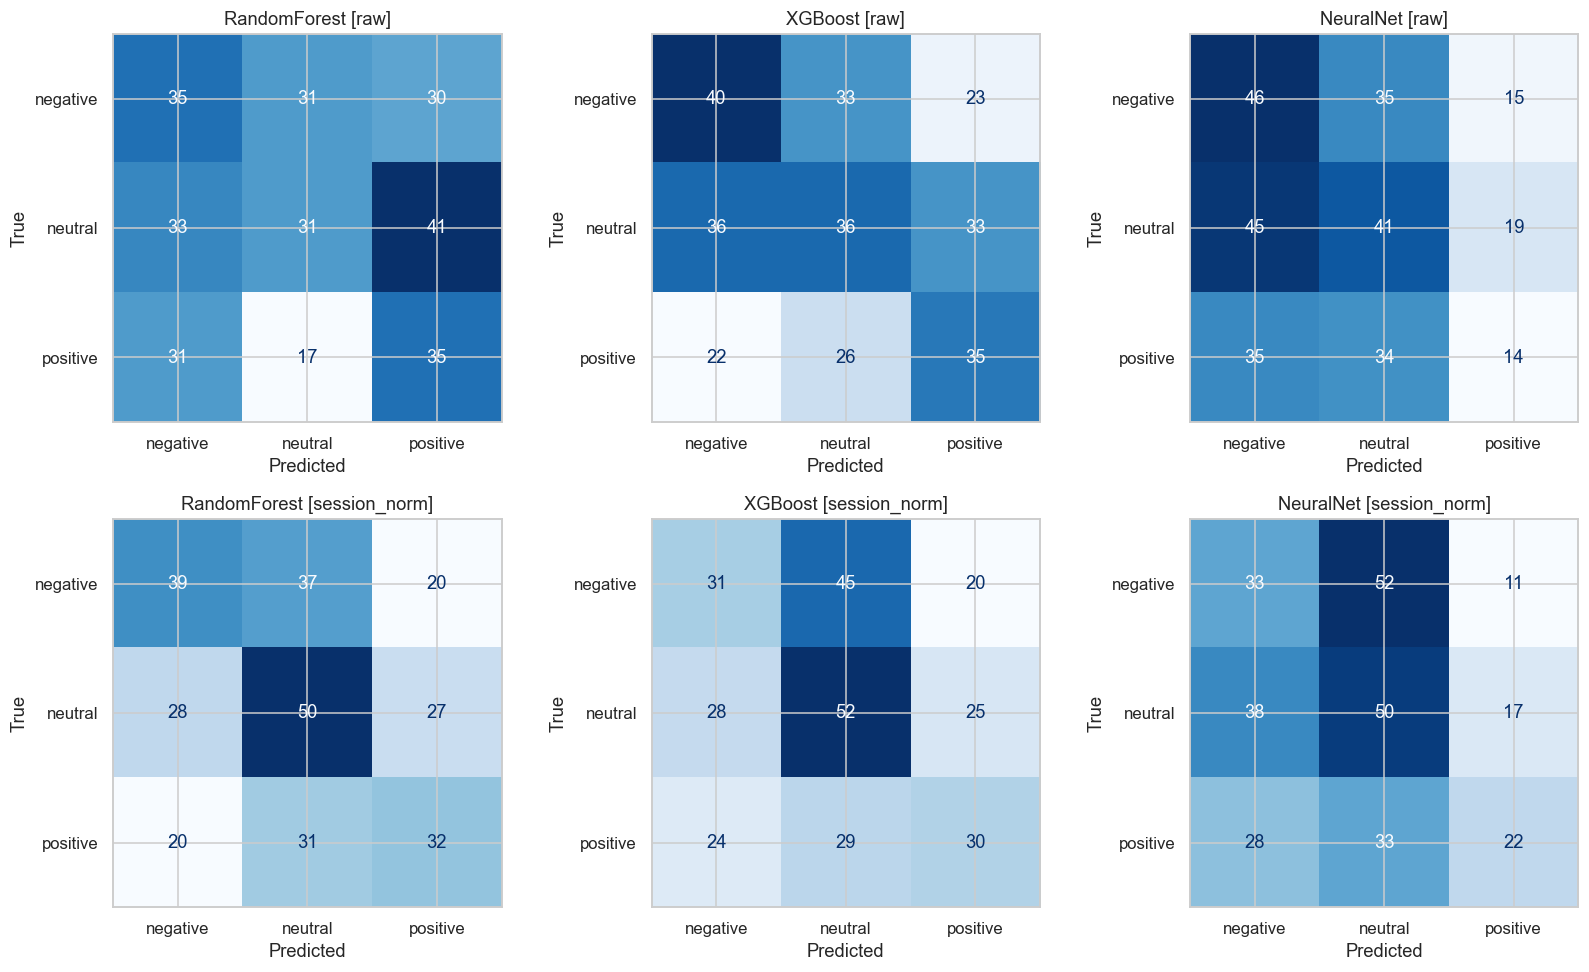

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, fset in enumerate(X_by_set):
    for col, name in enumerate(["RandomForest", "XGBoost", "NeuralNet"]):
        ax = axes[row, col]
        if (name, fset) not in results:
            ax.axis("off"); continue
        r = results[(name, fset)]
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=list(range(len(classes))))
        disp = ConfusionMatrixDisplay(cm, display_labels=classes)
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{name} [{fset}]")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

## 13  ROC Curves (one-vs-rest, pooled across all K folds, both feature sets)

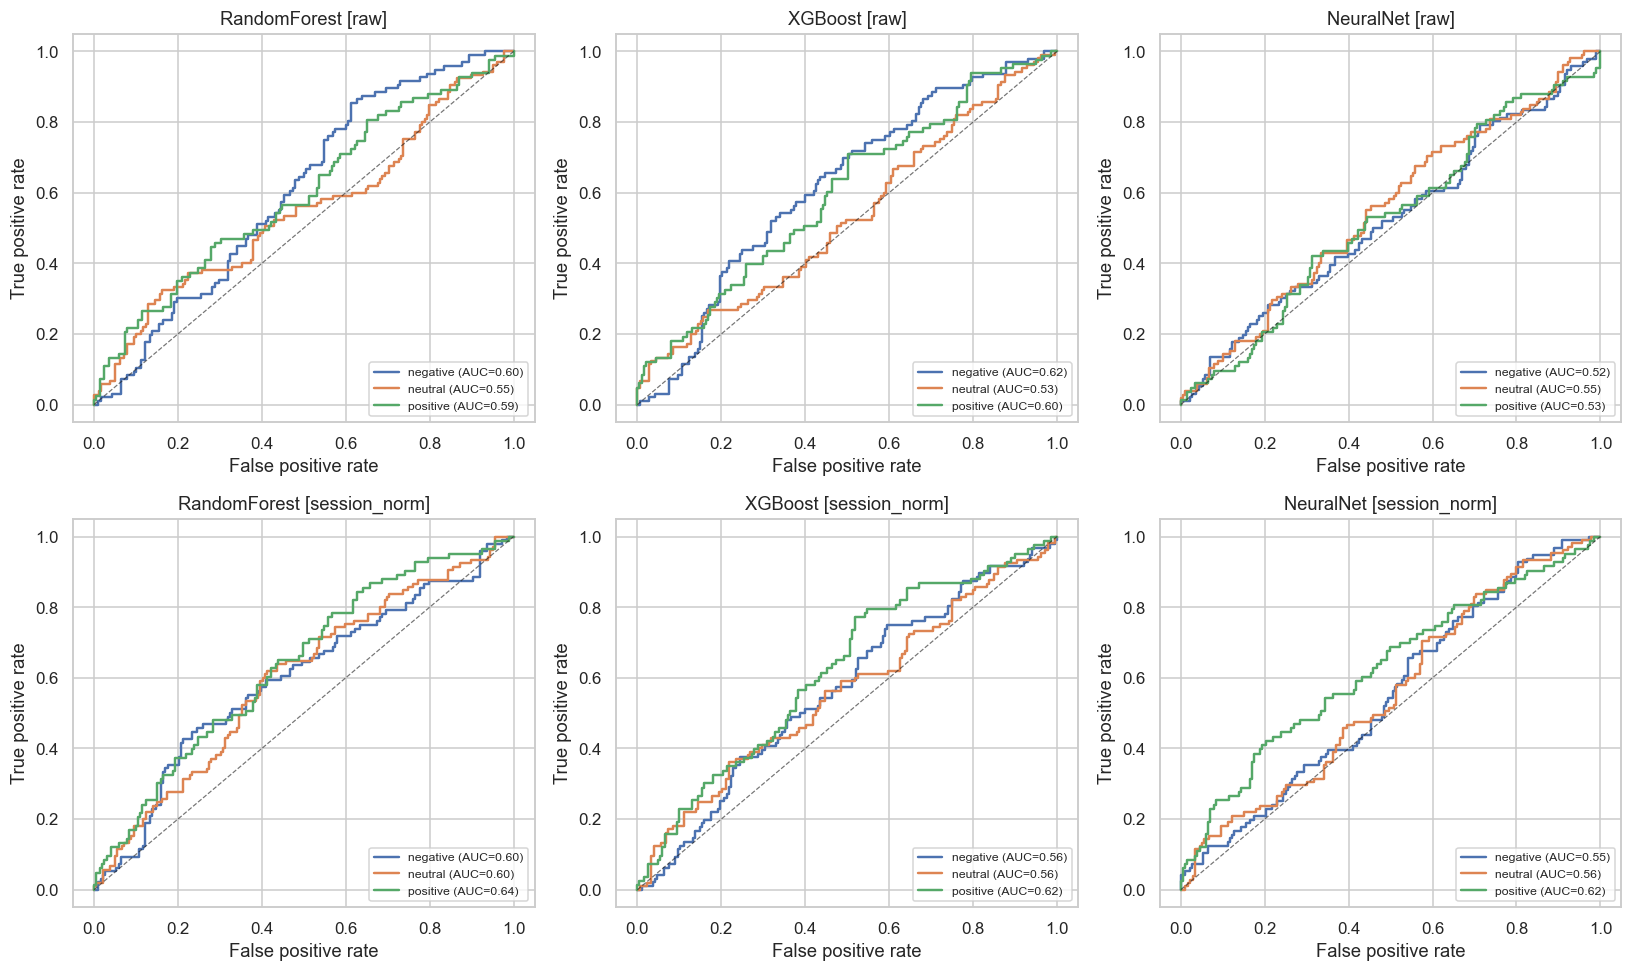

In [16]:
def plot_roc_ovr(y_true_all, y_proba_all, name, ax):
    y_bin = label_binarize(y_true_all, classes=list(range(len(classes))))
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    for i, cls in enumerate(classes):
        if y_bin[:, i].sum() == 0 or np.isnan(y_proba_all[:, i]).any():
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba_all[:, i])
        auc_i = roc_auc_score(y_bin[:, i], y_proba_all[:, i])
        ax.plot(fpr, tpr, lw=1.6, label=f"{cls} (AUC={auc_i:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.6)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"{name}"); ax.legend(fontsize=8, loc="lower right")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, fset in enumerate(X_by_set):
    for col, name in enumerate(["RandomForest", "XGBoost", "NeuralNet"]):
        ax = axes[row, col]
        if (name, fset) not in results:
            ax.axis("off"); continue
        r = results[(name, fset)]
        plot_roc_ovr(r["y_true"], r["y_proba"], f"{name} [{fset}]", ax)
plt.tight_layout(); plt.show()

## 14  Feature Importance (full-dataset-tuned models, §10b, both feature sets)

Tree-based models only (`RandomForest`, `XGBoost`) expose
`feature_importances_`; the MLP does not. These are the §7-10 full-dataset
models (§10b), not §11's nested-CV models — diagnostic only, not a reported
metric.


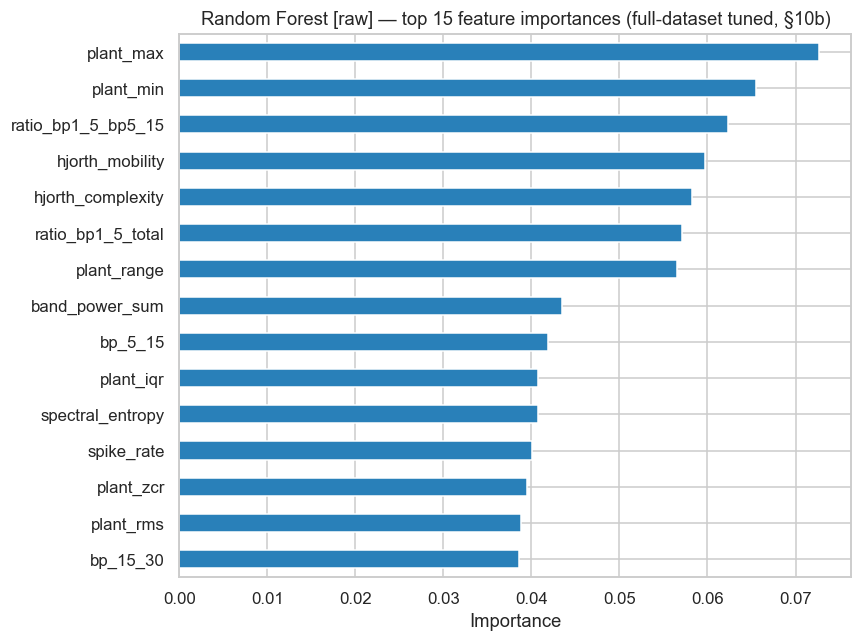

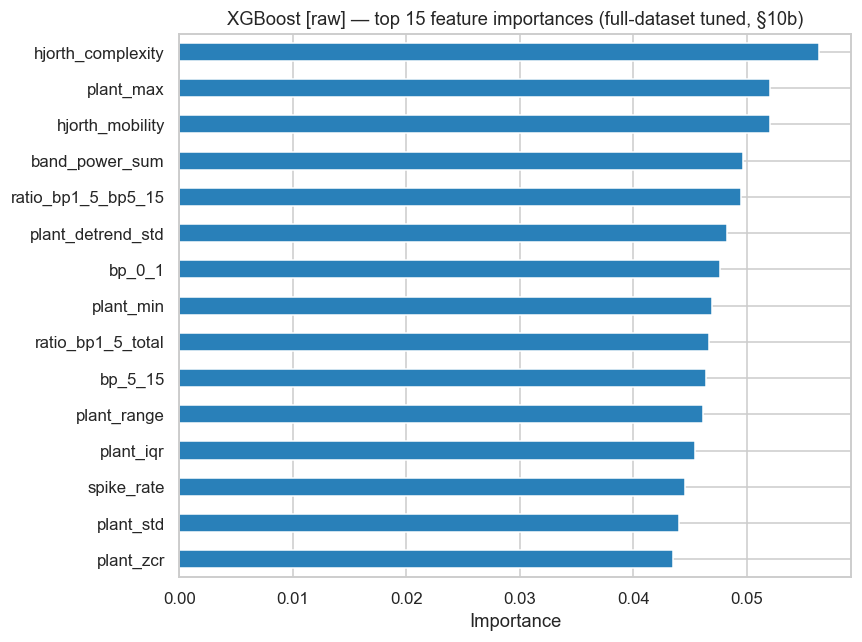

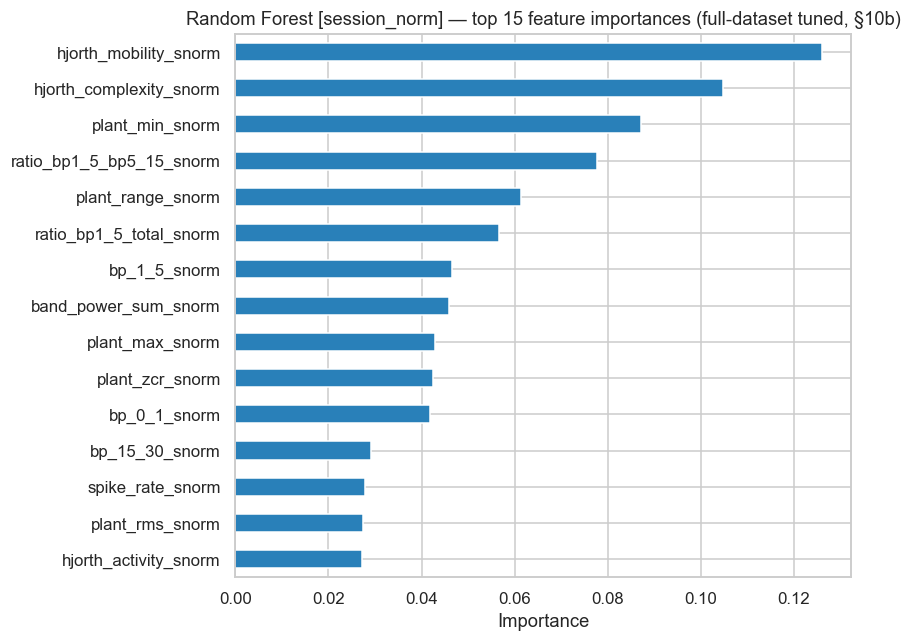

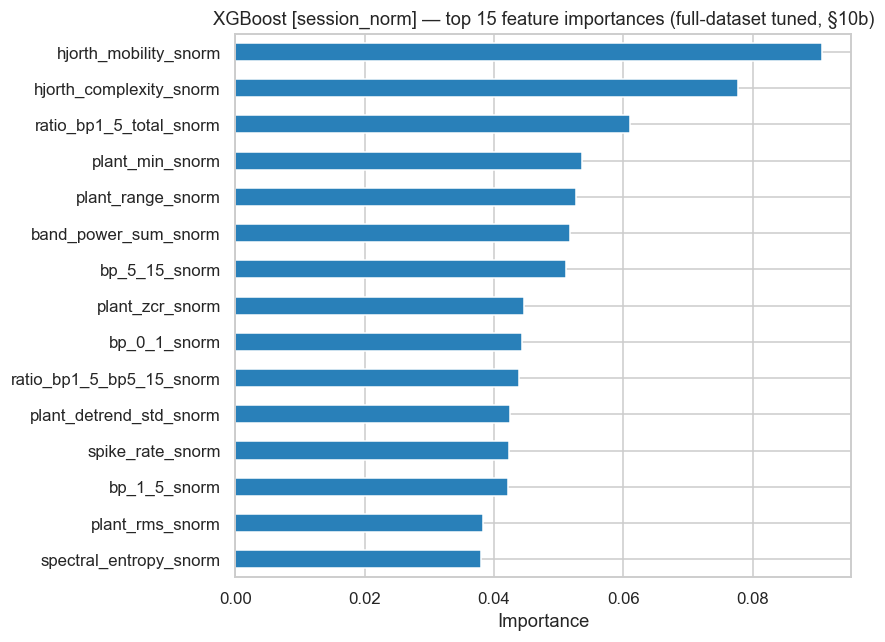

In [17]:
# §10b's tuned_models are already fit on the full dataset (GridSearchCV
# refit=True) - no separate refit needed here.
full_fit_models = tuned_models

def plot_importance(model, feature_names, name, top_n=15):
    est = model.named_steps["model"] if isinstance(model, Pipeline) else model
    if not hasattr(est, "feature_importances_"):
        print(f"{name} has no feature_importances_."); return None
    imp = pd.Series(est.feature_importances_, index=feature_names)
    imp = imp.sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(imp))))
    imp[::-1].plot.barh(ax=ax, color="#2980b9")
    ax.set_title(f"{name} — top {len(imp)} feature importances (full-dataset tuned, §10b)")
    ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()
    return imp

for fset, Xs in X_by_set.items():
    plot_importance(full_fit_models[("RandomForest", fset)], Xs.columns, f"Random Forest [{fset}]")
    if ("XGBoost", fset) in full_fit_models:
        plot_importance(full_fit_models[("XGBoost", fset)], Xs.columns, f"XGBoost [{fset}]")


## 15  Final Model Comparison (pooled K-fold, both feature sets)

Pooled 5-fold comparison, all (model, feature set) combinations, sorted by macro-F1:

                             accuracy  f1_macro  roc_auc
RandomForest [session_norm]     0.426     0.423    0.610
XGBoost [raw]                   0.391     0.392    0.583
XGBoost [session_norm]          0.398     0.392    0.581
NeuralNet [session_norm]        0.370     0.362    0.578
RandomForest [raw]              0.356     0.355    0.581
NeuralNet [raw]                 0.356     0.337    0.533

* Best-performing combination: RandomForest on the 'session_norm' feature set


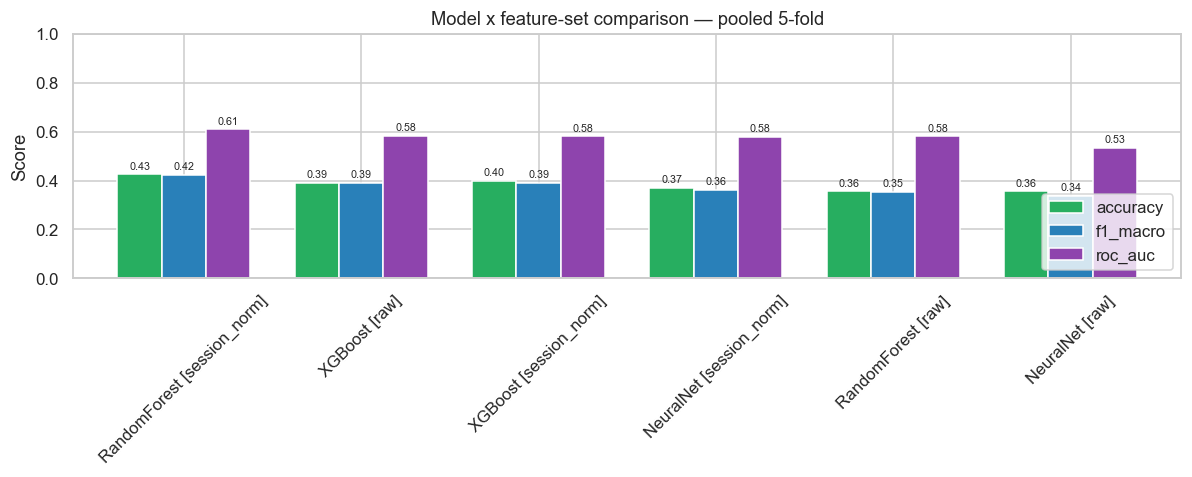

In [18]:
cmp = pd.DataFrame({f"{name} [{fset}]": {"accuracy": v["accuracy"], "f1_macro": v["f1_macro"], "roc_auc": v["roc_auc"]}
                     for (name, fset), v in results.items()}).T.round(3)
cmp = cmp.sort_values("f1_macro", ascending=False)
print(f"Pooled {CV_FOLDS}-fold comparison, all (model, feature set) combinations, sorted by macro-F1:\n")
print(cmp.to_string())

best_key_str = cmp.index[0]
best_name, best_fset = [s.strip() for s in best_key_str.replace("]", "").split("[")]
best_overall = (best_name, best_fset)
print(f"\n* Best-performing combination: {best_name} on the '{best_fset}' feature set")

ax = cmp.plot.bar(figsize=(11, 4.5), rot=45, width=0.75, color=["#27ae60", "#2980b9", "#8e44ad"])
ax.set_title(f"Model x feature-set comparison — pooled {CV_FOLDS}-fold")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout(); plt.show()

## 16  Persist the Best Model

The winner from §15 — the single best (model, feature set) combination by
pooled nested-CV macro-F1 — is refit here and saved to disk as a `.pkl`
file in `../models/`, named `<model_type>_<label_type>.pkl`. The bundle
records which feature set the model expects (`feature_set: "raw"` or
`"session_norm"`), so it's unambiguous later which of the two column
conventions a loaded model needs fed to it — the live dashboard doesn't
need this (it derives the expected columns straight from the model's own
`feature_names_in_`), but it makes the artifact self-describing for anyone
loading it by hand.

**This is a different fit from any fold in §11, deliberately.** The
nested-CV score in §15 estimates how well this (model, feature set)
approach generalizes to an unseen participant; the model persisted here is
separately tuned on **all** available data (§7-10's full-dataset tuning,
§10b) for production use, because a deployed model should use every
labelled window it can, not hold participants out the way an honest
evaluation must. Its hyperparameters may differ from any single outer
fold's, and it is not itself evaluated by the nested procedure — §15's
score is the number to trust for "how good is this approach", not a claim
about this specific file's held-out performance.


In [19]:
import pickle

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_TYPE = "valence"   # this notebook's target: the `valence_direction` axis
MODEL_SLUG = {"RandomForest": "random_forest", "XGBoost": "xgboost", "NeuralNet": "neural_network"}

best_name, best_fset = best_overall
best_estimator = full_fit_models[best_overall]   # already a Pipeline w/ scaler for NeuralNet

bundle = {
    "model": best_estimator,
    "classes": list(classes),
    "label_type": LABEL_TYPE,
    "model_type": best_name,
    "feature_set": best_fset,
}

model_path = MODELS_DIR / f"{MODEL_SLUG[best_name]}_{LABEL_TYPE}.pkl"
with open(model_path, "wb") as f:
    pickle.dump(bundle, f)

print(f"Persisted best model ({best_name} [{best_fset}], pooled nested {CV_FOLDS}-fold macro-F1="
      f"{cmp.loc[best_key_str, 'f1_macro']:.3f}) to: {model_path.resolve()}")
print(f"Classes: {bundle['classes']}")
print(f"Note: this file is separately tuned and fit on ALL {len(X_by_set[best_fset])} rows "
      f"(§7-10's full-dataset tuning, §10b) for production use; the reported macro-F1 is the "
      f"pooled nested-CV estimate from §11/§15, not a score on this file itself - see §16's "
      f"markdown for why these are deliberately different fits.")


Persisted best model (RandomForest [session_norm], pooled nested 5-fold macro-F1=0.423) to: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\models\random_forest_valence.pkl
Classes: ['negative', 'neutral', 'positive']
Note: this file is separately tuned and fit on ALL 284 rows (§7-10's full-dataset tuning, §10b) for production use; the reported macro-F1 is the pooled nested-CV estimate from §11/§15, not a score on this file itself - see §16's markdown for why these are deliberately different fits.


## 16b  Permutation Test — Is the Nested-CV Performance Real?

Re-running full nested hyperparameter search (§11) inside every one of
`N_PERMUTATIONS` permutations would multiply §11's already-nested runtime
by `N_PERMUTATIONS` again — computationally impractical here. This test
therefore uses a **disclosed, standard simplification**: it fixes the
winning combination's architecture at the hyperparameters §7-10's
full-dataset tuning found (`tuned_models[best_overall]`, the same estimator
persisted in §16), and refits *that* fixed architecture — no re-tuning per
fold, no re-tuning per permutation — across `StratifiedGroupKFold(CV_FOLDS)`
splits, once with the real labels and once per permutation with shuffled
labels.

Because the null distribution is built from this fixed-architecture
procedure, the **observed** statistic it is compared against is recomputed
the same way below, rather than reusing §15's nested-CV score directly —
comparing a null distribution to a differently-computed observed value
would give a miscalibrated p-value. Both numbers are printed, clearly
labelled, so neither is mistaken for the other: §15's nested-CV macro-F1
remains the honest generalization estimate; this section's observed
macro-F1 is the fixed-architecture number the permutation p-value actually
belongs to, and the two are typically close but not identical.


Winning combination: RandomForest [session_norm]
Nested-CV pooled 5-fold macro-F1 (§15, independently tuned per fold): 0.423
Fixed-architecture observed macro-F1 (this section, real labels):            0.467
Null distribution (200 label permutations, same fixed architecture, each a full 5-fold participant-grouped loop):
  mean = 0.324  std = 0.030  95th pct = 0.374  max = 0.400

Empirical p-value: 0.0050  (0/200 permutations matched or beat the real result)


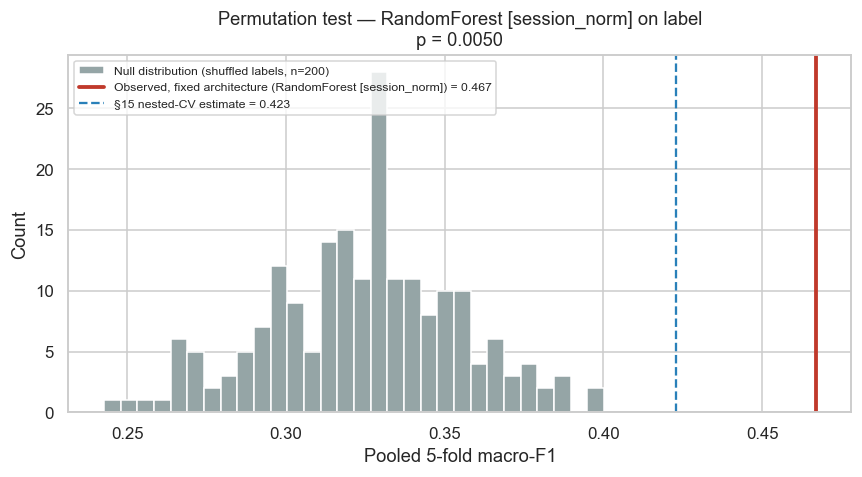

In [20]:
from sklearn.base import clone

N_PERMUTATIONS = 200
rng = np.random.RandomState(RANDOM_STATE)

winning_template = tuned_models[best_overall]   # fixed architecture - see §16b markdown
X_win = X_by_set[best_fset]
nested_cv_f1 = cmp.loc[best_key_str, "f1_macro"]   # §15's honest, independently-tuned-per-fold estimate


def _fixed_arch_pooled_f1(X, y):
    """One pass of StratifiedGroupKFold with the FIXED winning_template
    architecture (no re-tuning) - shared by the observed-value computation
    and every permutation below, so the two are directly comparable."""
    y_true_chunks, y_pred_chunks = [], []
    for train_idx, test_idx in EVAL_CV.split(X, y, groups):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        model = clone(winning_template)
        model.fit(X_tr, y_tr)
        y_pred_chunks.append(model.predict(X_te))
        y_true_chunks.append(y_te.values)
    return f1_score(np.concatenate(y_true_chunks), np.concatenate(y_pred_chunks),
                     average="macro", zero_division=0)


observed_f1 = _fixed_arch_pooled_f1(X_win, y_enc)

null_f1 = np.empty(N_PERMUTATIONS)
for i in range(N_PERMUTATIONS):
    y_shuffled_full = pd.Series(rng.permutation(y_enc.values), index=y_enc.index)
    null_f1[i] = _fixed_arch_pooled_f1(X_win, y_shuffled_full)

p_value = (1 + np.sum(null_f1 >= observed_f1)) / (1 + N_PERMUTATIONS)

print(f"Winning combination: {best_name} [{best_fset}]")
print(f"Nested-CV pooled {CV_FOLDS}-fold macro-F1 (§15, independently tuned per fold): {nested_cv_f1:.3f}")
print(f"Fixed-architecture observed macro-F1 (this section, real labels):            {observed_f1:.3f}")
print(f"Null distribution ({N_PERMUTATIONS} label permutations, same fixed architecture, "
      f"each a full {CV_FOLDS}-fold participant-grouped loop):")
print(f"  mean = {null_f1.mean():.3f}  std = {null_f1.std():.3f}  "
      f"95th pct = {np.percentile(null_f1, 95):.3f}  max = {null_f1.max():.3f}")
print(f"\nEmpirical p-value: {p_value:.4f}  "
      f"({int(np.sum(null_f1 >= observed_f1))}/{N_PERMUTATIONS} permutations matched or beat the real result)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(null_f1, bins=30, color="#95a5a6", edgecolor="white",
        label=f"Null distribution (shuffled labels, n={N_PERMUTATIONS})")
ax.axvline(observed_f1, color="#c0392b", lw=2.5,
           label=f"Observed, fixed architecture ({best_name} [{best_fset}]) = {observed_f1:.3f}")
ax.axvline(nested_cv_f1, color="#2980b9", lw=1.5, ls="--",
           label=f"§15 nested-CV estimate = {nested_cv_f1:.3f}")
ax.set_xlabel(f"Pooled {CV_FOLDS}-fold macro-F1"); ax.set_ylabel("Count")
ax.set_title(f"Permutation test — {best_name} [{best_fset}] on label\np = {p_value:.4f}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 17  Discussion, Conclusions & Future Work

### Why this evaluation is built the way it is
Every fold in this notebook — tuning and evaluation alike — is grouped by
`participant_id` via `StratifiedGroupKFold`, because windows from one
session share that participant's plant/electrode characteristics; a
non-grouped split would let a model partly learn "whose signal is this"
instead of the plant/valence relationship this pipeline exists to test
(§5). Hyperparameter tuning is **nested**: a fresh inner
`StratifiedGroupKFold` search runs on each outer fold's training data alone
(§11), so the reported macro-F1/accuracy/ROC-AUC numbers are never
influenced by the rows they are scored on. A **separate** full-dataset
tuning pass (§7-10) exists only to fit the model persisted for production
use (§16) and to inspect feature importances (§14) — it is not the source
of any reported metric, and deliberately uses all available data the way a
deployed model should, rather than holding participants out the way an
honest evaluation must.

Every model is tuned and evaluated on **both** feature sets — the raw
absolute-scale plant columns and the session-normalized `*_snorm` columns
(§3) — and §15 picks the single best (model, feature set) combination by
pooled nested-CV macro-F1 rather than assuming either representation
inherently helps.

This is a single flat classifier per combination throughout.

### Which model performed best, and why
The comparison in §15 selects the winner by pooled nested-CV macro-F1,
across all six (model, feature set) combinations.

### Which features contributed most
Read this off the feature-importance plots (§14) for whichever feature set
won. `valence_direction` is derived purely from facial expression (§4.6-4.8
of the labelling notebook), which has no known causal link to the plant's
bioelectric signal, so we do not expect a strong physiological reason for
any one plant feature to dominate here — a flat or noisy importance profile
would itself be an informative (negative) result.

### Honest limitations
- **Sample size.** With a pilot cohort (15 participants) the absolute
  scores carry wide confidence intervals; grouped K-fold reduces but does
  not eliminate this — see the per-fold macro-F1 spread printed in §11 and
  the class-support diagnostic printed before it.
- **Label provenance.** The target is a proxy label read **only** from
  facial expression (HSEmotion `enet_b0_8_va_mtl`) — see the labelling
  notebook's §4.12 for why this is not ground truth (no self-report, an
  imperfect direction estimator, and a participant who feels something
  without showing it is labelled `neutral`).
- **Nested tuning increases runtime.** §11 re-runs hyperparameter search
  inside every outer fold instead of once, which is why §7-10's grids were
  kept bounded (XGBoost's especially — `colsample_bytree` fixed while `subsample`
  is now tuned rather than held constant) to keep total runtime reasonable at this
  nesting depth.
- **The permutation test (§16b) does not re-tune per permutation.**
  Re-running nested tuning inside each of `N_PERMUTATIONS` permutations
  would multiply an already-nested runtime by `N_PERMUTATIONS` again —
  impractical here. It instead fixes the winning architecture at its
  full-dataset-tuned hyperparameters and refits only that, disclosed
  explicitly in §16b's markdown, with its own observed statistic computed
  the same way so the p-value stays calibrated against its own null
  distribution.
- **Session normalization is undefined for very short sessions.** Any
  session with fewer than `MIN_ML_WINDOWS` ML-grid windows gets `NaN`
  `*_snorm` columns (`02_emotion_labelling.ipynb` §4.10b), median-imputed
  like any other missing value here (§4) rather than treated specially —
  a handful of very short sessions may contribute less signal to the
  `session_norm` feature set than to `raw`.
- **The plant-voltage channel's physiological validity could not be
  confirmed**, and the hardware is no longer available to re-test — see
  the labelling notebook's §4.10 and §4.12 for the mains-interference
  analysis behind this.
- **Sample-rate caveat.** Spectral band edges (and the raw-signal features,
  which reuse the same measured rate) assume the true measured plant
  sampling rate (labelling notebook §4.10); if firmware timing changes,
  recompute.

### Future work
- Collect the full 10-15+ participant cohort and re-run — the pipeline
  already scales without changes.
- Record more sessions per participant to check how stable session-level
  normalization (§3, `02_emotion_labelling.ipynb` §4.10b) is within one
  person over time, now that it no longer depends on a single external
  baseline recording.
- Compare this notebook's results directly against
  `04_01_ml_pipeline_emotion.ipynb` and `04_02_ml_pipeline_arousal.ipynb` —
  since all three targets are derived from the same windows, differences in
  achievable accuracy are informative about which axis the plant signal
  tracks better.

---

*End of pipeline. The consolidated dataset and the three ML-pipeline
notebooks (crossed emotion, arousal, valence) form a reproducible path from
raw multi-session recordings to a compared set of classifiers per label
axis.*
